In [77]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [78]:
df=df.dropna(subset='salary_year_avg')

In [79]:
job_list=df['job_title_short'].value_counts().head(6).index.tolist()

In [80]:
df_jobs=df[df['job_title_short'].isin(job_list)]

In [81]:
temp=df_jobs.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False)

In [82]:
order=temp.index.to_list()

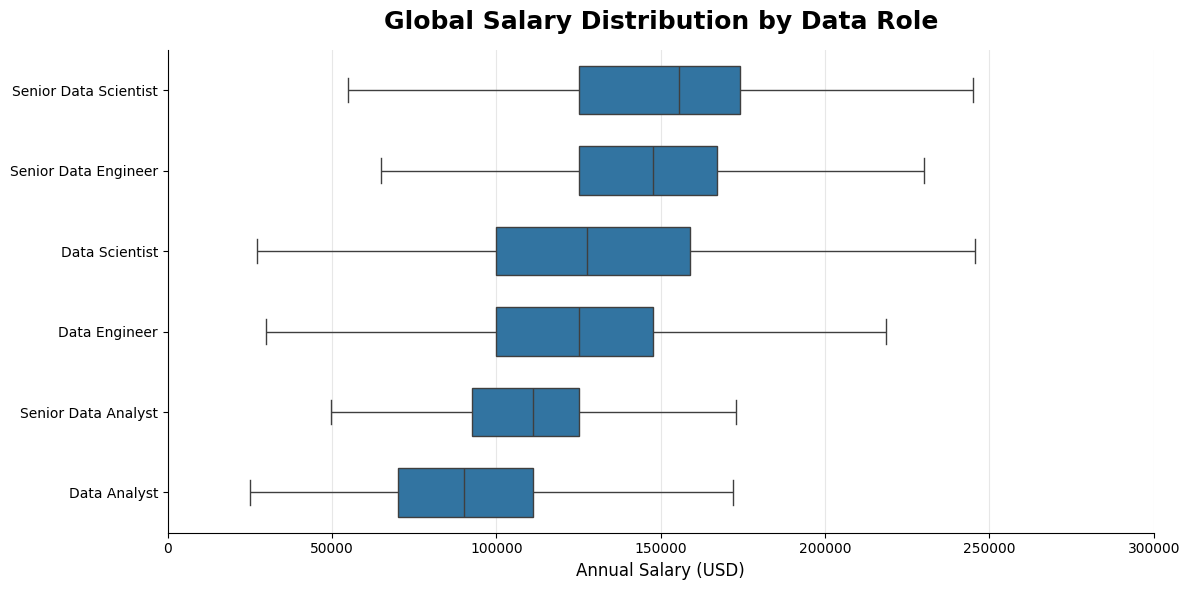

In [83]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_jobs,
    y='job_title_short',
    x='salary_year_avg',
    order=order,
    width=0.6,
    showfliers=False
)

sns.despine()

plt.title(
    'Global Salary Distribution by Data Role',
    fontsize=18,
    weight='bold',
    pad=15
)

plt.xlabel('Annual Salary (USD)', fontsize=12)
plt.ylabel('')

plt.grid(axis='x', alpha=0.3)

plt.xlim(0, 300000)

plt.tight_layout()
plt.show()

In [84]:
df_top_paid_skills=df.explode('job_skills')

In [85]:
df_top_paid_skills=df_top_paid_skills[df_top_paid_skills['job_title_short']=='Data Scientist'].groupby('job_skills')['salary_year_avg'].median().sort_values(ascending=False).head(10)

In [86]:
df_top_paid_skills=df_top_paid_skills.reset_index()

<Axes: xlabel='salary_year_avg', ylabel='job_skills'>

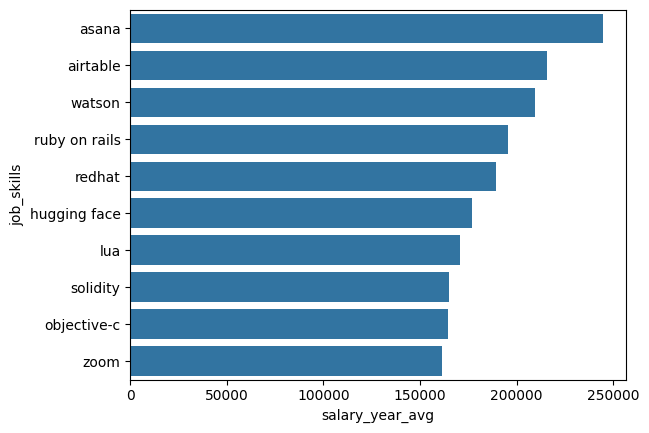

In [87]:
sns.barplot(data=df_top_paid_skills,x='salary_year_avg',y='job_skills')

In [88]:
df_top_demanded_skills=df.explode('job_skills')

In [89]:
df_top_demanded_skills=df_top_demanded_skills[df_top_demanded_skills['job_title_short']=='Data Scientist']

In [90]:
df_top_demanded_skills=df_top_demanded_skills['job_skills'].value_counts().head(10)
df_top_demanded_skills=df_top_demanded_skills.reset_index(name="job_count")

<Axes: xlabel='job_count', ylabel='job_skills'>

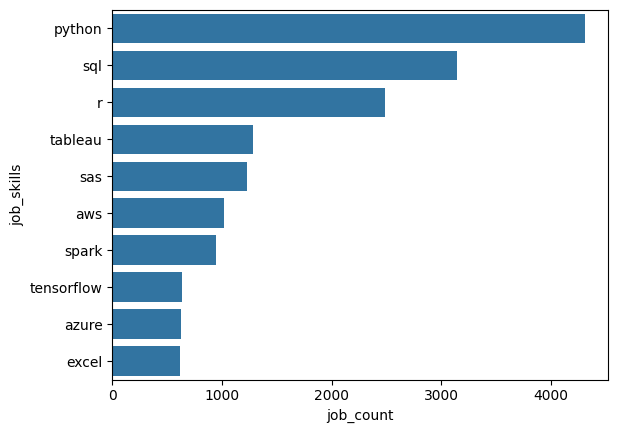

In [91]:
sns.barplot(data=df_top_demanded_skills,y='job_skills',x='job_count')


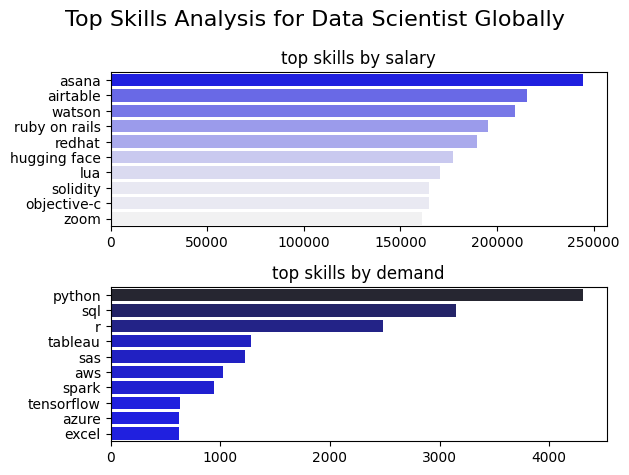

In [124]:
fig,ax=plt.subplots(2,1)

fig.suptitle("Top Skills Analysis for Data Scientist Globally", fontsize=16)

sns.barplot(data=df_top_paid_skills,x='salary_year_avg',y='job_skills',ax=ax[0],hue='salary_year_avg',palette='light:b',legend=False)
ax[0].set_title("top skills by salary")
sns.barplot(data=df_top_demanded_skills,y='job_skills',x='job_count',ax=ax[1],hue='job_count',palette='dark:b_r',legend=False)
ax[1].set_title("top skills by demand")
ax[0].set_ylabel("")
ax[1].set_ylabel("")
ax[1].set_xlabel("")
ax[0].set_xlabel("")
plt.tight_layout()